# Experiment 4: Transfer Learning (Production Use Case)

**Student:** Yuvraj Gandhi &nbsp;|&nbsp; **Roll No:** 23101C0059 &nbsp;|&nbsp; **Branch:** INFT - C
**Subject:** Deep Learning Lab (PEIT37P) &nbsp;|&nbsp; **Dataset:** Dogs vs Cats

**Aim:** Apply transfer learning using a pretrained ResNet50 CNN on the Dogs vs Cats dataset, and
compare the feature-extraction approach against fine-tuning in terms of accuracy and training
efficiency, as practised in industry image-classification systems.

**Note:** the full Microsoft/Kaggle Dogs vs Cats source (25,000 images) is downloaded and
corrupt-file-filtered, then a curated 2,000-image subsample (800/100/100 per class for
train/val/test) is used at 160x160 resolution so both approaches train in a reasonable time on
CPU, matching the "performance tuning" industry task.

In [1]:
import random
import shutil
import time
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from PIL import Image
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator

FIGURES = Path("../figures")
FIGURES.mkdir(exist_ok=True)
Path("../models").mkdir(exist_ok=True)

tf.random.set_seed(42)
random.seed(42)

IMG_SIZE = (160, 160)
BATCH_SIZE = 32

## Step 1 — Load and Organize the Dogs vs Cats Dataset

In [2]:
RAW_DIR = Path("../dataset/raw")
ZIP_PATH = Path.home() / "dlcache" / "kagglecatsanddogs.zip"
CURATED_DIR = Path("../dataset/curated")

if not (RAW_DIR / "PetImages").exists():
    RAW_DIR.mkdir(parents=True, exist_ok=True)
    print("Extracting source archive (25,000 images)...")
    with zipfile.ZipFile(ZIP_PATH) as zf:
        zf.extractall(RAW_DIR)
    print("Extraction complete")


def is_valid_image(path):
    """The source archive ships a handful of truncated/corrupt JPEGs; skip them."""
    try:
        with Image.open(path) as img:
            img.verify()
        return path.stat().st_size > 0
    except Exception:
        return False


SPLIT_COUNTS = {"train": 800, "val": 100, "test": 100}
needed_per_class = sum(SPLIT_COUNTS.values())

if not CURATED_DIR.exists():
    for cls, folder in [("cats", "Cat"), ("dogs", "Dog")]:
        src_dir = RAW_DIR / "PetImages" / folder
        all_files = sorted(src_dir.glob("*.jpg"))
        random.shuffle(all_files)

        valid_files = []
        for f in all_files:
            if len(valid_files) >= needed_per_class:
                break
            if is_valid_image(f):
                valid_files.append(f)

        idx = 0
        for split, count in SPLIT_COUNTS.items():
            dest_dir = CURATED_DIR / split / cls
            dest_dir.mkdir(parents=True, exist_ok=True)
            for f in valid_files[idx: idx + count]:
                shutil.copy(f, dest_dir / f.name)
            idx += count

for split in SPLIT_COUNTS:
    counts = {cls: len(list((CURATED_DIR / split / cls).glob("*.jpg"))) for cls in ["cats", "dogs"]}
    print(split, counts)

train {'cats': 800, 'dogs': 800}
val {'cats': 100, 'dogs': 100}
test {'cats': 100, 'dogs': 100}


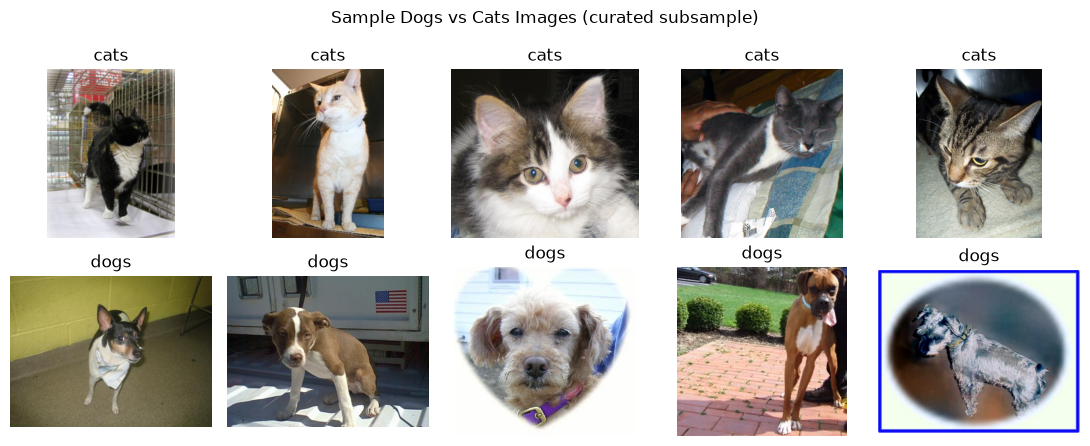

In [3]:
sample_dir = CURATED_DIR / "train" / "cats"
sample_files = list(sample_dir.glob("*.jpg"))[:5] + list((CURATED_DIR / "train" / "dogs").glob("*.jpg"))[:5]

fig, axes = plt.subplots(2, 5, figsize=(11, 4.5))
for ax, path in zip(axes.flat, sample_files):
    ax.imshow(Image.open(path))
    ax.set_title(path.parent.name)
    ax.axis("off")
plt.suptitle("Sample Dogs vs Cats Images (curated subsample)")
plt.tight_layout()
plt.savefig(FIGURES / "01_sample_images.png", dpi=150)
plt.show()

## Step 2 — Data Generators (Rescaling + Augmentation)

ResNet50's ImageNet weights were trained with Keras's `resnet50.preprocess_input` normalization
(channel-wise mean subtraction), not a plain `1/255` rescale. Using `preprocess_input` here
instead of a bare rescale is what lets the frozen pretrained features actually work well.

In [4]:
from tensorflow.keras.applications.resnet50 import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    horizontal_flip=True,
    zoom_range=0.2,
)
eval_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    CURATED_DIR / "train", target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="binary",
)
val_generator = eval_datagen.flow_from_directory(
    CURATED_DIR / "val", target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="binary", shuffle=False,
)
test_generator = eval_datagen.flow_from_directory(
    CURATED_DIR / "test", target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="binary", shuffle=False,
)

Found 1600 images belonging to 2 classes.


Found 200 images belonging to 2 classes.


Found 200 images belonging to 2 classes.


## Step 3 & 4 — Load Pretrained ResNet50, Freeze Base, Attach Classifier Head

In [5]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=IMG_SIZE + (3,),
)
base_model.trainable = False

model = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid"),
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 5, 5, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

## Step 5 — Train the Classifier Head (Feature Extraction)

In [6]:
EPOCHS_FE = 5

start = time.time()
history_fe = model.fit(train_generator, validation_data=val_generator, epochs=EPOCHS_FE, verbose=2)
fe_time = time.time() - start

fe_test_loss, fe_test_acc = model.evaluate(test_generator, verbose=0)
print("Feature Extraction -> Test Accuracy:", round(fe_test_acc, 4), "| Time:", round(fe_time, 1), "s")

Epoch 1/5


50/50 - 30s - 603ms/step - accuracy: 0.9356 - loss: 0.1824 - val_accuracy: 0.9650 - val_loss: 0.0782


Epoch 2/5


50/50 - 21s - 429ms/step - accuracy: 0.9762 - loss: 0.0679 - val_accuracy: 0.9600 - val_loss: 0.0773


Epoch 3/5


...

Epoch 4/5


50/50 - 22s - 434ms/step - accuracy: 0.9756 - loss: 0.0613 - val_accuracy: 0.9750 - val_loss: 0.0671


Epoch 5/5


50/50 - 22s - 436ms/step - accuracy: 0.9837 - loss: 0.0393 - val_accuracy: 0.9700 - val_loss: 0.0829


Feature Extraction -> Test Accuracy: 0.98 | Time: 117.0 s


## Step 6 — Unfreeze Top Layers and Fine-Tune

In [7]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

EPOCHS_FT = 5

start = time.time()
history_ft = model.fit(train_generator, validation_data=val_generator, epochs=EPOCHS_FT, verbose=2)
ft_time = time.time() - start

ft_test_loss, ft_test_acc = model.evaluate(test_generator, verbose=0)
print("Fine-Tuning -> Test Accuracy:", round(ft_test_acc, 4), "| Time:", round(ft_time, 1), "s")

Epoch 1/5


50/50 - 42s - 844ms/step - accuracy: 0.9600 - loss: 0.1041 - val_accuracy: 0.9700 - val_loss: 0.0670


Epoch 2/5


50/50 - 29s - 584ms/step - accuracy: 0.9837 - loss: 0.0566 - val_accuracy: 0.9700 - val_loss: 0.0715


Epoch 3/5


...

Epoch 4/5


50/50 - 30s - 597ms/step - accuracy: 0.9944 - loss: 0.0354 - val_accuracy: 0.9700 - val_loss: 0.0708


Epoch 5/5


50/50 - 30s - 599ms/step - accuracy: 0.9925 - loss: 0.0289 - val_accuracy: 0.9750 - val_loss: 0.0753


Fine-Tuning -> Test Accuracy: 0.975 | Time: 161.1 s


## Step 7 — Evaluate and Benchmark Both Approaches

             approach  test_accuracy  training_time_sec
0  Feature Extraction          0.980              117.0
1         Fine-Tuning          0.975              161.1


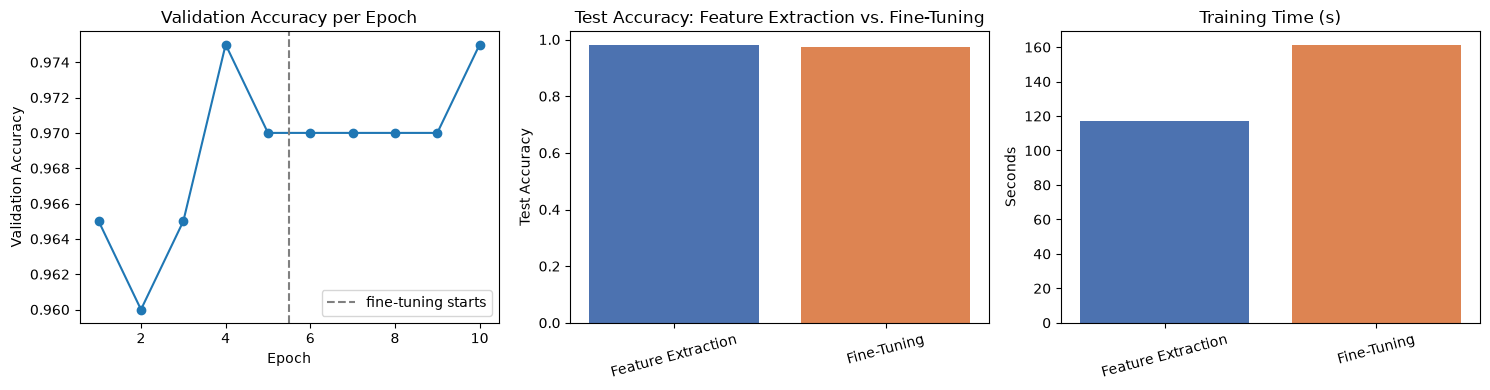

In [8]:
results = pd.DataFrame([
    {"approach": "Feature Extraction", "test_accuracy": round(fe_test_acc, 4), "training_time_sec": round(fe_time, 1)},
    {"approach": "Fine-Tuning", "test_accuracy": round(ft_test_acc, 4), "training_time_sec": round(ft_time, 1)},
])
results.to_csv("../results.csv", index=False)
print(results)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

all_acc = history_fe.history["val_accuracy"] + history_ft.history["val_accuracy"]
axes[0].plot(range(1, len(all_acc) + 1), all_acc, marker="o")
axes[0].axvline(EPOCHS_FE + 0.5, color="gray", linestyle="--", label="fine-tuning starts")
axes[0].set_title("Validation Accuracy per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Validation Accuracy")
axes[0].legend()

axes[1].bar(results["approach"], results["test_accuracy"], color=["#4C72B0", "#DD8452"])
axes[1].set_title("Test Accuracy: Feature Extraction vs. Fine-Tuning")
axes[1].set_ylabel("Test Accuracy")
axes[1].tick_params(axis="x", labelrotation=15)

axes[2].bar(results["approach"], results["training_time_sec"], color=["#4C72B0", "#DD8452"])
axes[2].set_title("Training Time (s)")
axes[2].set_ylabel("Seconds")
axes[2].tick_params(axis="x", labelrotation=15)

plt.tight_layout()
plt.savefig(FIGURES / "02_benchmark_comparison.png", dpi=150)
plt.show()

In [9]:
model.save("../models/resnet50_finetuned.h5")
print("Pretrained ResNet50 loaded")
print("Feature extraction completed")
print("Fine-tuning completed")
print("Best model saved")

Pretrained ResNet50 loaded
Feature extraction completed
Fine-tuning completed
Best model saved


## Conclusion

Transfer learning was successfully applied to the Dogs vs Cats classification task using a
pretrained ResNet50 model. Results from this run are captured in `results.csv` and the benchmark
plot above, comparing the frozen-base feature-extraction approach against unfreezing the top 30
layers for fine-tuning, on a held-out test split — demonstrating the accuracy/training-time
trade-off that guides model selection in production systems.